# Fractionally Differentiate Features

## Overview

This notebook demonstrates the public functions in `fractionally_differentiate_features` using dollar-bar close prices built from a raw Alpaca trade file.
- The notebook inspects fractional-differencing weights for several orders.
- It applies both expanding-window and fixed-width fractional differencing to the same close series.
- It compares the transformed outputs against the original close path.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
sys.path.insert(0, str(root))

In [2]:
from src.data_preprocessing.fractionally_differentiate_features import (
    fractional_difference,
    fractional_difference_fixed_width,
    get_weights,
    get_weights_fixed_width,
    plot_min_ffd,
    plot_weights,
)
from src.data_preprocessing.financial_data_structures import get_dollar_bars

## Load raw Alpaca trades

This section reads the same AAPL trade file used by the other preprocessing notebooks and resamples it into dollar bars.
- The transformed feature input is the dollar-bar close series.
- The notebook keeps the input as a single-column pandas `DataFrame` because the module expects tabular input.
- The dollar-bar threshold is derived from `target_bars_per_day = 24` and the number of distinct trading dates in the raw trade sample.
- Using the same raw source file keeps the examples aligned across notebooks.


In [3]:
alpaca_path = root / "data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet"

trades = pd.read_parquet(alpaca_path).sort_values("timestamp").reset_index(drop=True)[
    ["timestamp", "symbol", "price", "size"]].copy()
notional = trades["price"].astype(float) * trades["size"].astype(float)
target_bars_per_day = 24
trading_days = trades["timestamp"].dt.normalize().nunique()
target_num_bars = max(1, trading_days * target_bars_per_day)
dollar_threshold = float(notional.sum() / target_num_bars)
dollar_bars = get_dollar_bars(trades, threshold=dollar_threshold).ohlcv
close_frame = dollar_bars[["close"]].astype(float)

print(f"source: {alpaca_path.relative_to(root)}")
print(f"trading_days: {trading_days}")
print(f"target_bars_per_day: {target_bars_per_day}")
print(f"num_dollar_bars: {len(close_frame):,}")
close_frame.head()

source: data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet
trading_days: 20
target_bars_per_day: 24
num_dollar_bars: 479


,close
end,
2026-01-02 14:41:10.943383+00:00,274.28
2026-01-02 14:48:49.651065+00:00,277.18
2026-01-02 15:00:22.257127+00:00,277.11
2026-01-02 15:14:20.199050+00:00,275.72
2026-01-02 15:30:31.439947+00:00,273.23


### Interpretation

The feature notebook is working with the same event-time close path as the labeling notebooks, but it uses that path to study memory removal instead of labels.
- Under the current `target_bars_per_day = 24` rule, the AAPL sample again becomes `479` dollar bars, which is long enough for both expanding-window and fixed-width differencing to be visible.
- Because every later transformation starts from `close_frame`, the amount of apparent persistence or stationarity you see below is a property of this resampled series rather than of raw trade ticks.
- Using dollar bars here matters: with only a daily series, the ADF diagnostic would have far fewer observations and much less power.


## Inspect Fractional-Differencing Weights

This section checks the expanding-window weights, the fixed-width cutoff weights, and the multi-curve weight plot.
- `get_weights` returns a length-controlled weight vector for the expanding-window method.
- `get_weights_fixed_width` truncates the tail once the next weight falls below the cutoff threshold.
- `plot_weights` makes it easier to compare how the weight profile changes as `d` increases.


In [4]:
weight_example = pd.DataFrame(get_weights(d=0.4, size=8).T, columns=[f"w_{i}" for i in range(8)])
weight_example

,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7
0,-0.018371,-0.022963,-0.029952,-0.0416,-0.064,-0.12,-0.4,1.0


In [5]:
fixed_width_weights = get_weights_fixed_width(d=0.4, thres=0.05)
fixed_width_weight_example = pd.DataFrame(
    fixed_width_weights.T,
    columns=[f"w_{i}" for i in range(fixed_width_weights.shape[0])],
)
fixed_width_weight_example

,w_0,w_1,w_2,w_3
0,-0.064,-0.12,-0.4,1.0


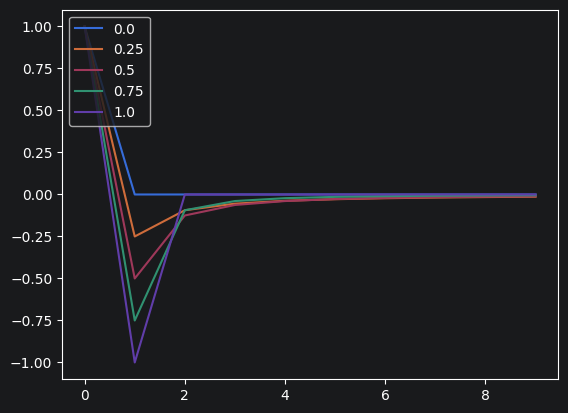

In [6]:
plot_weights(dRange=[0.0, 1.0], nPlots=5, size=10)

### Interpretation

The weight examples make the differencing rule concrete before you look at any transformed price path.
- For `d = 0.4` and `size = 8`, the expanding-window weights are approximately `[-0.0184, -0.0230, -0.0300, -0.0416, -0.0640, -0.1200, -0.4000, 1.0000]`, so the current bar gets the dominant weight but several lagged bars still matter.
- The fixed-width version with `thres = 0.05` keeps only four weights, about `[-0.0640, -0.1200, -0.4000, 1.0000]`, which shows exactly how the cutoff truncates the far tail of the memory kernel.
- In the multi-curve plot, increasing `d` should steepen the negative lag structure; on this dataset that means progressively more low-frequency trend is being removed from the same 479-bar close path.


## Apply Fractional Differencing

This section applies both fractional-differencing variants to the same close series.
- `fractional_difference` uses an expanding window and skips early samples based on cumulative weight loss.
- `fractional_difference_fixed_width` uses a fixed window determined by the weight cutoff threshold.
- Comparing both outputs helps show the tradeoff between memory retention and a stable sample width.

In [7]:
ffd_expanding = fractional_difference(close_frame, d=0.4, thres=0.01)
ffd_fixed = fractional_difference_fixed_width(close_frame, d=0.4, thres=1e-3)

pd.Series(
    {
        "original_rows": len(close_frame),
        "expanding_rows": len(ffd_expanding),
        "fixed_width_rows": len(ffd_fixed),
    },
    name="num_rows",
).to_frame()

,num_rows
original_rows,479
expanding_rows,248
fixed_width_rows,425


,original_close,expanding_ffd,fixed_width_ffd
end,,,
2026-01-16 16:49:12.964158+00:00,256.25,18.475721,34.067277
2026-01-16 17:06:56.797325+00:00,256.27,18.645097,34.269514
2026-01-16 17:33:47.734192+00:00,255.50,17.912704,33.570550
2026-01-16 17:53:08.286631+00:00,255.29,18.028870,33.721209
2026-01-16 18:25:20.540529+00:00,255.75,18.672501,34.398371


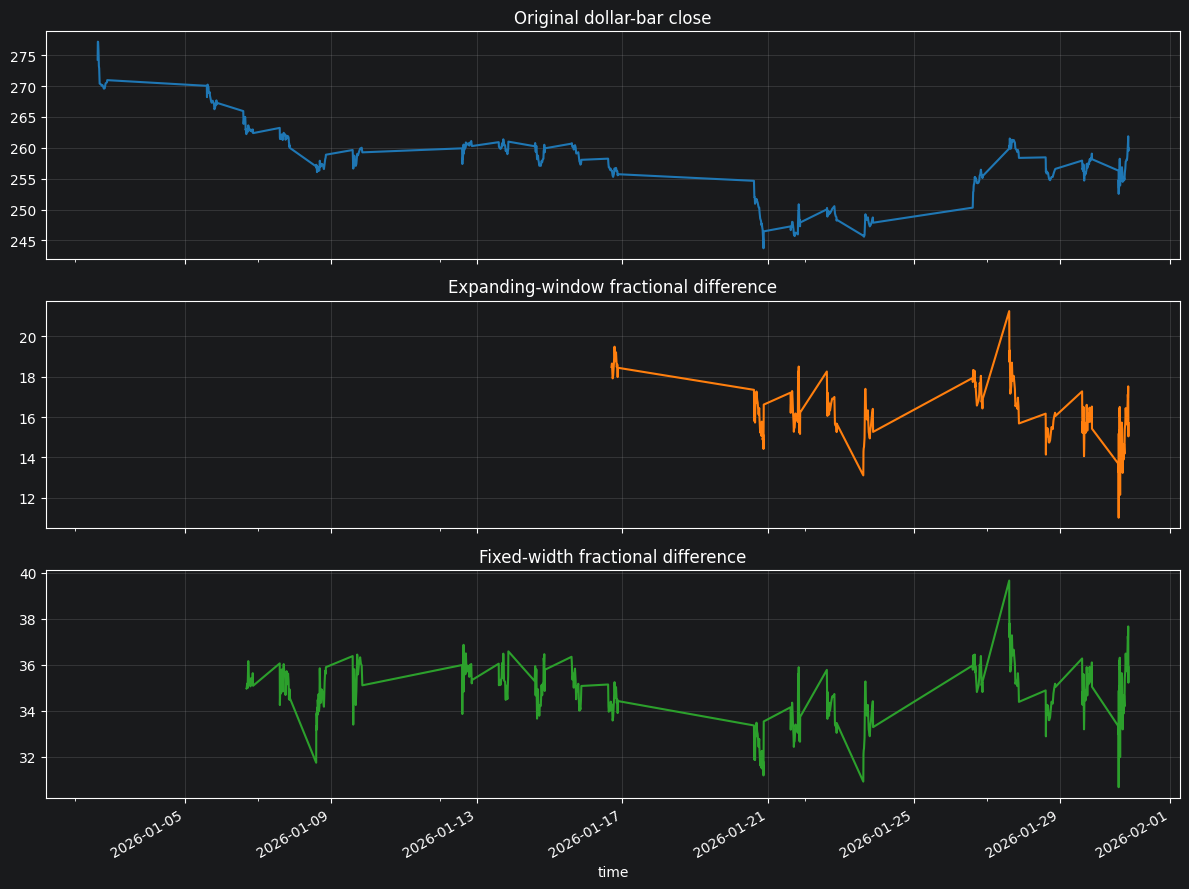

In [8]:
comparison = close_frame.rename(columns={"close": "original_close"}).join(
    ffd_expanding.rename(columns={"close": "expanding_ffd"}),
    how="left",
).join(
    ffd_fixed.rename(columns={"close": "fixed_width_ffd"}),
    how="left",
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
comparison["original_close"].plot(ax=axes[0], color="tab:blue", title="Original dollar-bar close")
comparison["expanding_ffd"].plot(ax=axes[1], color="tab:orange", title="Expanding-window fractional difference")
comparison["fixed_width_ffd"].plot(ax=axes[2], color="tab:green", title="Fixed-width fractional difference")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xlabel("time")

fig.tight_layout()
comparison.dropna().head()

### Interpretation

The transformed series are useful only if they remove persistence without destroying too much of the local structure.
- On this run the expanding-window transform keeps `248` rows, while the fixed-width transform keeps `425`, so the fixed-width variant preserves many more usable observations.
- That row-count gap is the practical cost of the expanding-window method here: it uses a longer effective history, but the price is a much later starting point for the transformed series.
- If the fixed-width panel still tracks short-term turning points while losing the broad price drift seen in the original close panel, it is usually the more convenient feature for downstream modeling.


## Minimum-FFD Diagnostic

This section runs the notebook-friendly `plot_min_ffd` implementation on the dollar-bar close series loaded above.
- The helper applies fixed-width fractional differencing across a grid of `d` values.
- It compares the transformed series against the original log-close path with both ADF statistics and correlation.
- The plot is rendered directly in the notebook, and the diagnostic table is returned for inspection below.


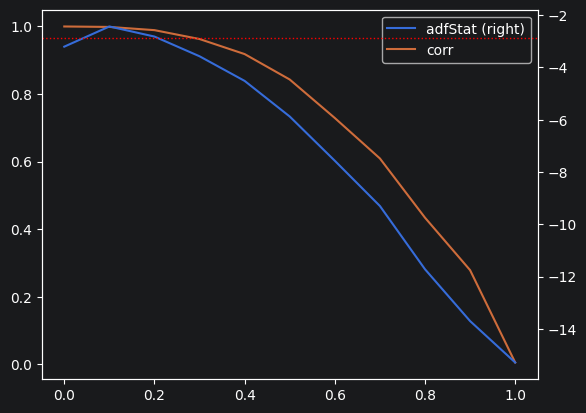

,adfStat,pVal,lags,nObs,95% conf,corr
0.0,-3.209516,1.944045e-02,1.0,477.0,-2.867618,1.000000
0.1,-2.437757,1.313622e-01,1.0,470.0,-2.867709,0.998654
0.2,-2.823366,5.501285e-02,1.0,467.0,-2.867749,0.989138
0.3,-3.577369,6.208720e-03,1.0,466.0,-2.867762,0.962797
0.4,-4.519120,1.815749e-04,1.0,467.0,-2.867749,0.918250
0.5,-5.880793,3.081873e-07,1.0,468.0,-2.867736,0.842906
0.6,-7.573267,2.804593e-11,1.0,469.0,-2.867722,0.728876
0.7,-9.302955,1.099893e-15,1.0,471.0,-2.867696,0.609076
0.8,-11.722733,1.400797e-21,1.0,472.0,-2.867683,0.433615
0.9,-13.703996,1.273956e-25,1.0,474.0,-2.867657,0.278240


In [9]:
min_ffd_diagnostic = plot_min_ffd(close_frame, thres=0.01)
min_ffd_diagnostic

### Interpretation

The minimum-FFD table should be read as a tradeoff between statistical stationarity and information retention.
- At `d = 0.0`, the diagnostic already has `477` usable observations, `adfStat ≈ -3.21`, and `pVal ≈ 0.019`, so this dollar-bar log-price series is already stationary enough to pass the ADF check under the current setup.
- `d = 0.1` weakens that conclusion (`pVal ≈ 0.131`), while `d = 0.3` restores a strong pass (`pVal ≈ 0.006`) with `corr ≈ 0.963`, making it a plausible compromise if you still want explicit fractional differencing.
- By `d = 0.4`, stationarity is even stronger (`pVal ≈ 0.00018`) but the correlation drops to about `0.918`, so the table is showing exactly where extra differencing begins to cost noticeable information.
